# 1 eMBB UE / 3 gNB PRB Accounting - 5 Minutes

This notebook runs one moving eMBB UE in a 3-gNB topology for 5 minutes with a coherent 1 ms radio tick. It tracks radio metrics and separates PRB accounting into allocated, useful/used, wasted, and demand PRBs.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env

plt.rcParams.update({"figure.dpi": 125, "axes.grid": True, "grid.alpha": 0.25})
np.set_printoptions(precision=3, suppress=True)

In [2]:
SEED = 20260617
SIM_DURATION_S = 5 * 60
RADIO_DT_S = 1e-3
N_TICKS = int(SIM_DURATION_S / RADIO_DT_S)
PLOT_MAX_POINTS = 6000
SLICE_TYPE = "eMBB"

gnb_configs = [
    {"id": 0, "x": 0.0, "y": 0.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
    {"id": 1, "x": 450.0, "y": 0.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
    {"id": 2, "x": 225.0, "y": 390.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
]

ue_spec = {
    "x": 80.0,
    "y": 25.0,
    "vx": 1.2,
    "vy": 0.35,
    "slice_type": SLICE_TYPE,
    "bit_rate": 2_000_000.0,
    "packet_size_bits": 1000.0,
    "traffic_model": "fixed_packet_cbr",
}

print(f"Simulating {SIM_DURATION_S} seconds = {N_TICKS:,} coherent 1 ms ticks")

Simulating 300 seconds = 300,000 coherent 1 ms ticks


In [3]:
def sample_for_plot(df, max_points=PLOT_MAX_POINTS):
    if len(df) <= max_points:
        return df
    step = int(np.ceil(len(df) / max_points))
    out = df.iloc[::step].copy()
    if out.index[-1] != df.index[-1]:
        out = pd.concat([out, df.tail(1)], axis=0)
    return out

def fading_state(env, ue_id):
    state = env._fading_users.get(int(ue_id), {})
    return {
        "fading_trace_idx": state.get("trace_idx", np.nan),
        "fading_column_idx": state.get("index", np.nan),
        "fading_step_direction": state.get("step", np.nan),
        "fading_n_columns": state.get("n_cols", np.nan),
    }

def collect_row(env, ue_id, tick, info):
    ue = env.get_ue(ue_id)
    radio = env.get_ue_radio_metrics(ue_id)
    serving = -1 if radio["serving_gnb"] is None else int(radio["serving_gnb"])
    kpi = info["slice_kpis"].get((serving, SLICE_TYPE), {}) if serving >= 0 else {}

    row = {
        "tick": int(tick),
        "time_s": tick * RADIO_DT_S,
        "time_ms": tick * RADIO_DT_S * 1000.0,
        "x": float(ue.x),
        "y": float(ue.y),
        "vx": float(ue.vx),
        "vy": float(ue.vy),
        "serving_gnb": serving,
        "connected": bool(radio["connected"]),
        "sinr_db": float(radio["sinr_db"]),
        "scheduled_sinr_db": float(radio["scheduled_sinr_db"]),
        "snr_db": float(radio["snr_db"]),
        "rsrp_dbm": float(radio["rsrp_dbm"]),
        "rssi_dbm": float(radio["rssi_dbm"]),
        "rsrq_db": float(radio["rsrq_db"]),
        "rx_power_dbm": float(radio["rx_power_dbm"]),
        "interference_dbm": float(radio["interference_dbm"]),
        "noise_dbm": float(radio["noise_dbm"]),
        "mcs": int(radio["mcs"]),
        "spectral_efficiency": float(radio["spectral_efficiency"]),
        "rx_probability": float(radio["rx_probability"]),
        "allocated_prbs": int(radio["allocated_prbs"]),
        "used_prbs": int(radio["used_prbs"]),
        "useful_prbs": int(radio["useful_prbs"]),
        "wasted_prbs": int(radio["wasted_prbs"]),
        "demand_prbs": int(kpi.get("demand_prbs", 0)),
        "budget_prbs": int(kpi.get("budget_prbs", 0)),
        "allocated_load": float(kpi.get("allocated_load", 0.0)),
        "used_load": float(kpi.get("used_load", 0.0)),
        "wasted_load": float(kpi.get("wasted_load", 0.0)),
        "demand_load": float(kpi.get("demand_load", 0.0)),
        "new_bits": float(radio["new_bits"]),
        "scheduled_bits": float(radio["scheduled_bits"]),
        "served_bits": float(radio["served_bits"]),
        "queue_bits": float(radio["queue"]),
        "throughput_bps": float(radio["throughput"]),
        "tx_success_ratio": float(kpi.get("tx_success_ratio", 0.0)),
    }
    row.update(fading_state(env, ue_id))

    for gnb in env.gnbs:
        gnb_id = int(gnb.id)
        link = env._compute_link_metrics(gnb, ue)
        row[f"g{gnb_id}_sinr_db"] = float(link["sinr_db"])
        row[f"g{gnb_id}_rsrp_dbm"] = float(link["rsrp_dbm"])
        row[f"g{gnb_id}_rsrq_db"] = float(link["rsrq_db"])
    return row

In [4]:
rng = np.random.default_rng(SEED)
env = create_multignb_env(
    rng=rng,
    n=4,
    gnb_configs=gnb_configs,
    slots_per_step=5,
    L1_level=False,
    step_dt=RADIO_DT_S,
    mobility_dt=RADIO_DT_S,
    radio_substeps=1,
    max_episode_steps=N_TICKS + 5,
)
env.reset(seed=SEED)
ue_id = env.add_ue(**ue_spec)

rows = []
for tick in range(1, N_TICKS + 1):
    _obs, _reward, terminated, truncated, info = env.step(0)
    rows.append(collect_row(env, ue_id, tick, info))
    if terminated or truncated:
        break

trace = pd.DataFrame(rows)
env.close()

display(trace.head())
display(trace.tail())
print("rows", len(trace), "final_time_s", trace["time_s"].iloc[-1])

,tick,time_s,time_ms,x,y,vx,vy,serving_gnb,connected,sinr_db,...,fading_n_columns,g0_sinr_db,g0_rsrp_dbm,g0_rsrq_db,g1_sinr_db,g1_rsrp_dbm,g1_rsrq_db,g2_sinr_db,g2_rsrp_dbm,g2_rsrq_db
0,1,0.001,1.0,80.0012,25.00035,1.2,0.35,0,True,21.713246,...,10001,21.713246,-62.477955,19.970826,-20.0,-86.762284,-4.313503,-20.0,-87.699362,-5.250581
1,2,0.002,2.0,80.0024,25.00070,1.2,0.35,0,True,21.712960,...,10001,21.712960,-62.478199,19.970824,-20.0,-86.762233,-4.313210,-20.0,-87.699330,-5.250308
2,3,0.003,3.0,80.0036,25.00105,1.2,0.35,0,True,21.712674,...,10001,21.712674,-62.478442,19.970822,-20.0,-86.762181,-4.312917,-20.0,-87.699298,-5.250034
3,4,0.004,4.0,80.0048,25.00140,1.2,0.35,0,True,21.712387,...,10001,21.712387,-62.478686,19.970820,-20.0,-86.762129,-4.312623,-20.0,-87.699266,-5.249761
4,5,0.005,5.0,80.0060,25.00175,1.2,0.35,0,True,21.712101,...,10001,21.712101,-62.478929,19.970818,-20.0,-86.762078,-4.312330,-20.0,-87.699234,-5.249487


,tick,time_s,time_ms,x,y,vx,vy,serving_gnb,connected,sinr_db,...,fading_n_columns,g0_sinr_db,g0_rsrp_dbm,g0_rsrq_db,g1_sinr_db,g1_rsrp_dbm,g1_rsrq_db,g2_sinr_db,g2_rsrp_dbm,g2_rsrq_db
299995,299996,299.996,299996.0,439.9952,129.99860,1.2,0.35,0,True,-20.0,...,10001,-20.0,-90.237722,-0.701926,14.332354,-69.693072,19.842724,-15.563148,-85.217933,4.317863
299996,299997,299.997,299997.0,439.9964,129.99895,1.2,0.35,0,True,-20.0,...,10001,-20.0,-90.237767,-0.701939,14.332351,-69.693104,19.842724,-15.563140,-85.217957,4.317871
299997,299998,299.998,299998.0,439.9976,129.99930,1.2,0.35,0,True,-20.0,...,10001,-20.0,-90.237811,-0.701951,14.332348,-69.693136,19.842724,-15.563131,-85.217981,4.317879
299998,299999,299.999,299999.0,439.9988,129.99965,1.2,0.35,0,True,-20.0,...,10001,-20.0,-90.237856,-0.701963,14.332344,-69.693169,19.842724,-15.563123,-85.218005,4.317888
299999,300000,300.000,300000.0,440.0000,130.00000,1.2,0.35,0,True,-20.0,...,10001,-20.0,-90.237900,-0.701976,14.332341,-69.693201,19.842724,-15.563115,-85.218029,4.317896


rows 300000 final_time_s 300.0


In [5]:
assert np.allclose(trace["time_ms"].diff().dropna(), 1.0)
assert (trace["allocated_prbs"] == trace["used_prbs"] + trace["wasted_prbs"]).all()
assert (trace["used_prbs"] == trace["useful_prbs"]).all()
assert (trace["allocated_prbs"] <= trace["budget_prbs"]).all()

summary = pd.DataFrame({
    "metric": [
        "rows", "time_span_s", "max_allocated_prbs", "mean_allocated_prbs",
        "max_used_prbs", "mean_used_prbs", "max_wasted_prbs", "mean_wasted_prbs",
        "max_demand_prbs", "mean_sinr_db", "mean_rsrp_dbm", "mean_rsrq_db",
        "total_scheduled_bits", "total_served_bits", "max_queue_bits",
    ],
    "value": [
        len(trace), float(trace["time_s"].iloc[-1]), float(trace["allocated_prbs"].max()), float(trace["allocated_prbs"].mean()),
        float(trace["used_prbs"].max()), float(trace["used_prbs"].mean()), float(trace["wasted_prbs"].max()), float(trace["wasted_prbs"].mean()),
        float(trace["demand_prbs"].max()), float(trace["sinr_db"].mean()), float(trace["rsrp_dbm"].mean()), float(trace["rsrq_db"].mean()),
        float(trace["scheduled_bits"].sum()), float(trace["served_bits"].sum()), float(trace["queue_bits"].max()),
    ],
})
display(summary)

,metric,value
0,rows,3.000000e+05
1,time_span_s,3.000000e+02
2,max_allocated_prbs,1.000000e+02
3,mean_allocated_prbs,1.000000e+02
4,max_used_prbs,1.000000e+02
5,mean_used_prbs,6.836872e+01
6,max_wasted_prbs,9.700000e+01
7,mean_wasted_prbs,3.163128e+01
8,max_demand_prbs,5.111724e+06
9,mean_sinr_db,-3.959964e+00


Text(0.5, 1.0, '3 gNB topology and UE path')

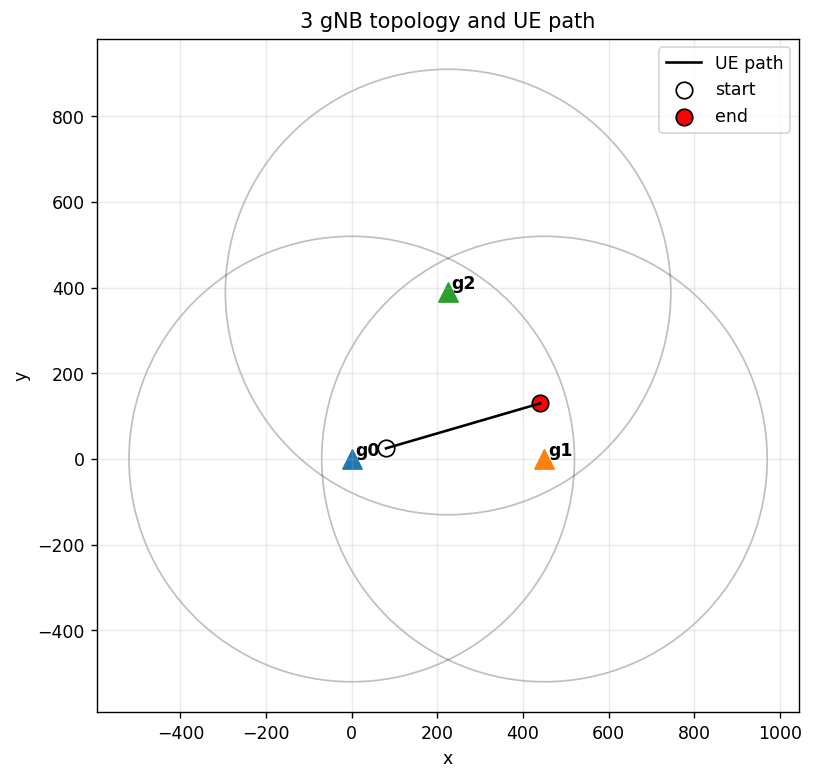

In [6]:
plot_trace = sample_for_plot(trace)

fig, ax = plt.subplots(figsize=(8, 7))
for cfg in gnb_configs:
    circle = plt.Circle((cfg["x"], cfg["y"]), cfg["coverage_radius"], fill=False, alpha=0.25)
    ax.add_patch(circle)
    ax.scatter(cfg["x"], cfg["y"], marker="^", s=120)
    ax.text(cfg["x"] + 8, cfg["y"] + 8, f"g{cfg['id']}", weight="bold")
ax.plot(plot_trace["x"], plot_trace["y"], color="black", label="UE path")
ax.scatter(trace["x"].iloc[0], trace["y"].iloc[0], color="white", edgecolor="black", s=90, label="start")
ax.scatter(trace["x"].iloc[-1], trace["y"].iloc[-1], color="red", edgecolor="black", s=90, label="end")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("3 gNB topology and UE path")

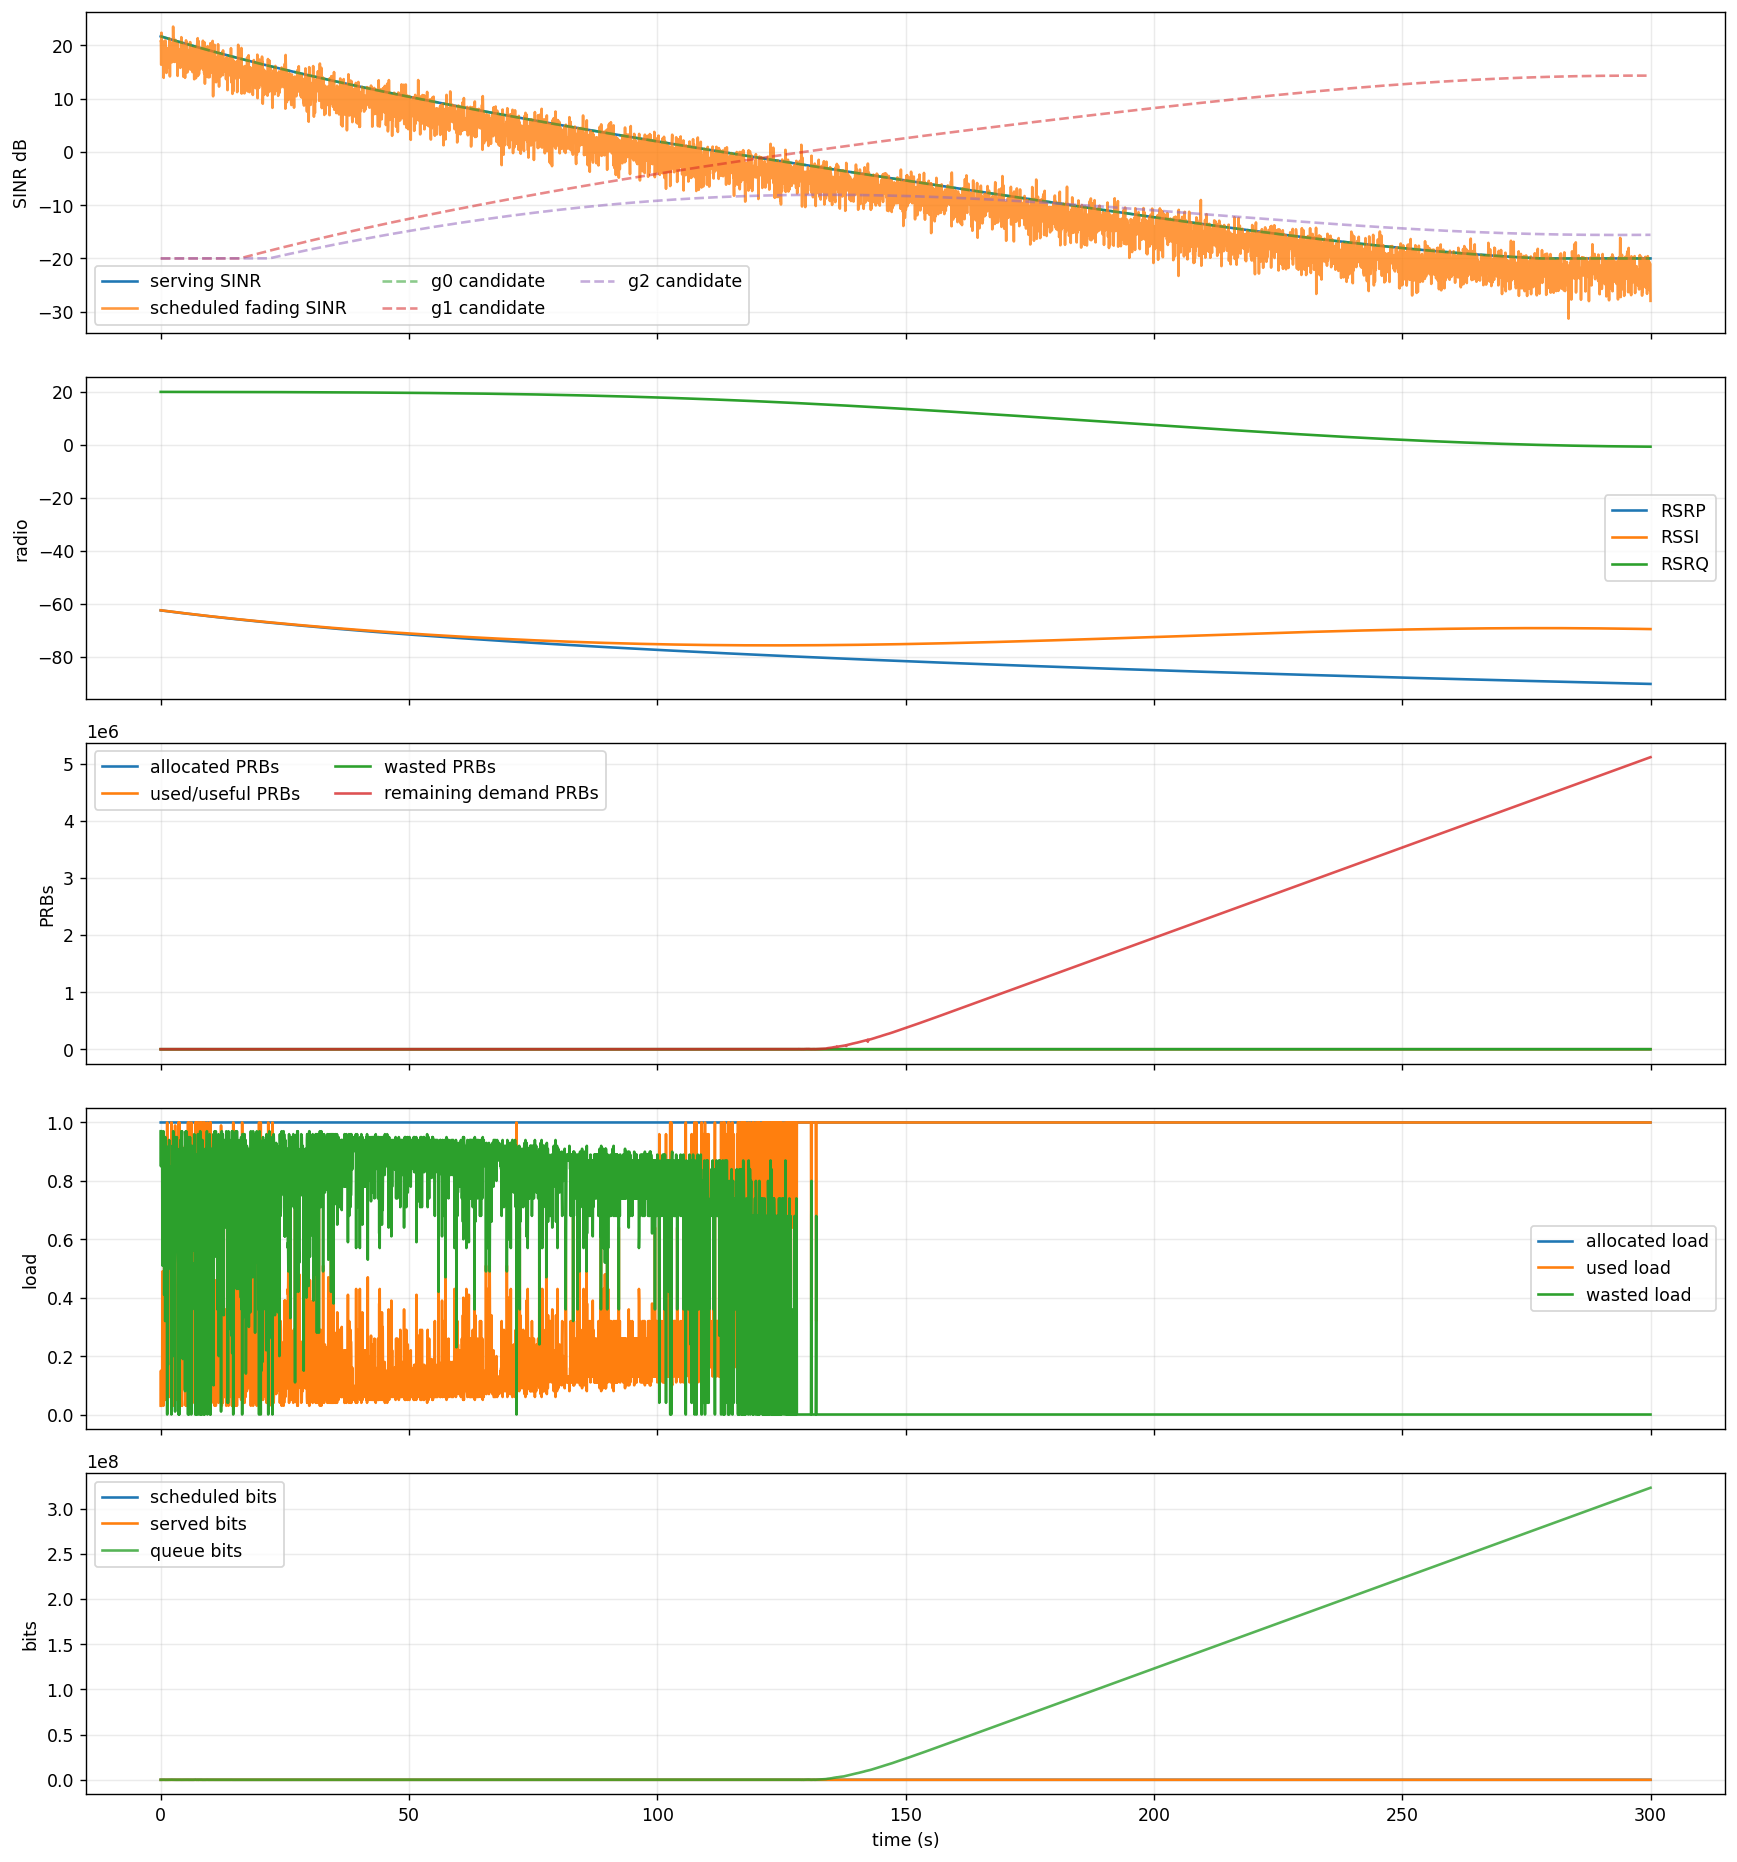

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
axes[0].plot(plot_trace["time_s"], plot_trace["sinr_db"], label="serving SINR")
axes[0].plot(plot_trace["time_s"], plot_trace["scheduled_sinr_db"], label="scheduled fading SINR", alpha=0.8)
for g in range(3):
    axes[0].plot(plot_trace["time_s"], plot_trace[f"g{g}_sinr_db"], linestyle="--", alpha=0.55, label=f"g{g} candidate")
axes[0].set_ylabel("SINR dB")
axes[0].legend(ncol=3)

axes[1].plot(plot_trace["time_s"], plot_trace["rsrp_dbm"], label="RSRP")
axes[1].plot(plot_trace["time_s"], plot_trace["rssi_dbm"], label="RSSI")
axes[1].plot(plot_trace["time_s"], plot_trace["rsrq_db"], label="RSRQ")
axes[1].set_ylabel("radio")
axes[1].legend()

axes[2].plot(plot_trace["time_s"], plot_trace["allocated_prbs"], label="allocated PRBs")
axes[2].plot(plot_trace["time_s"], plot_trace["used_prbs"], label="used/useful PRBs")
axes[2].plot(plot_trace["time_s"], plot_trace["wasted_prbs"], label="wasted PRBs")
axes[2].plot(plot_trace["time_s"], plot_trace["demand_prbs"], label="remaining demand PRBs", alpha=0.8)
axes[2].set_ylabel("PRBs")
axes[2].legend(ncol=2)

axes[3].plot(plot_trace["time_s"], plot_trace["allocated_load"], label="allocated load")
axes[3].plot(plot_trace["time_s"], plot_trace["used_load"], label="used load")
axes[3].plot(plot_trace["time_s"], plot_trace["wasted_load"], label="wasted load")
axes[3].set_ylabel("load")
axes[3].legend()

axes[4].plot(plot_trace["time_s"], plot_trace["scheduled_bits"], label="scheduled bits")
axes[4].plot(plot_trace["time_s"], plot_trace["served_bits"], label="served bits")
axes[4].plot(plot_trace["time_s"], plot_trace["queue_bits"], label="queue bits", alpha=0.8)
axes[4].set_ylabel("bits")
axes[4].set_xlabel("time (s)")
axes[4].legend()

fig.tight_layout()

In [8]:
out_dir = PROJECT_ROOT / "results" / "one_embb_3gnb_prb_accounting_5min"
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "radio_prb_trace.csv"
trace.to_csv(csv_path, index=False)
csv_path

PosixPath('/home/oussama/Desktop/chech/results/one_embb_3gnb_prb_accounting_5min/radio_prb_trace.csv')